<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print("tamanho treino: ", len(x_train))
print("tamanho teste: ", len(x_test))
print("tamanho treino: ", len(y_train))
print("tamanho teste: ", len(y_test))


tamanho treino:  105
tamanho teste:  45
tamanho treino:  105
tamanho teste:  45


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier()
tree.fit(x_train, y_train)

train_accuracy = tree.score(x_train, y_train)
test_accuracy = tree.score(x_test, y_test)
print("Acurácia treino:", train_accuracy)
print("Acurácia teste:", test_accuracy)

Acurácia treino: 1.0
Acurácia teste: 1.0


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

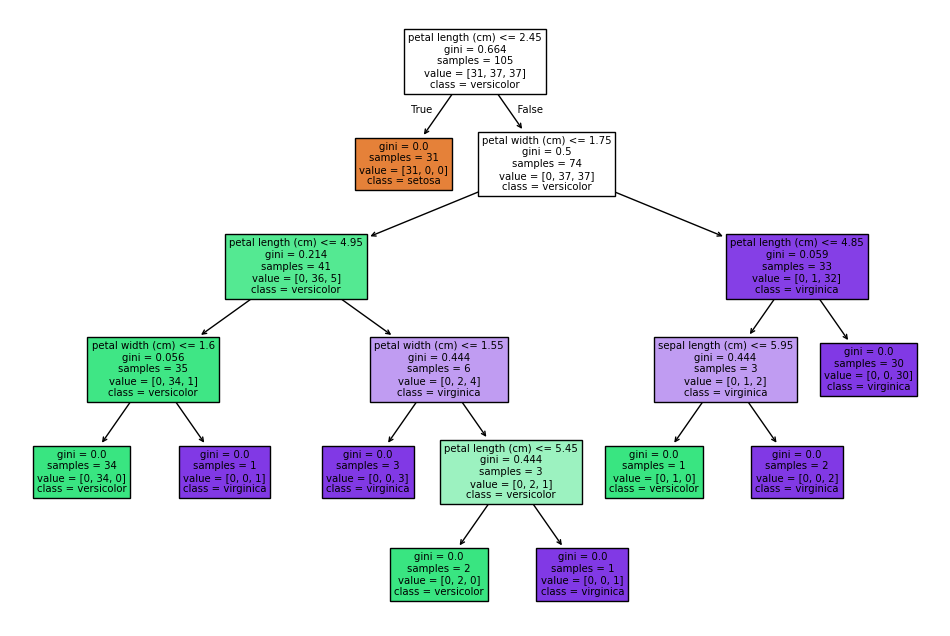

Atributo na raiz: petal length (cm)
Profundidade da árvore: 5


In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()

root_feature_index = tree.tree_.feature[0]
atributo_raiz = data.feature_names[root_feature_index]


depth = tree.get_depth()
print("Atributo na raiz:", atributo_raiz)
print("Profundidade da árvore:", depth)

**Adicione seu texto de solução aqui**.

E possivel que o primeiro atriburo da raiz sejao petal length (cm) e que possui a profundidade 5 (essas informaçãos são verificadas no print)

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [6]:
import pandas as pd

depths = list(range(1,10)) + [None]
results = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(x_train, y_train)
    train_acc = clf.score(x_train, y_train)
    test_acc = clf.score(x_test, y_test)
    depth_actual = clf.get_depth()
    n_leaves = clf.get_n_leaves()
    results.append({'max_depth': d, 'train_accuracy': train_acc, 'test_accuracy': test_acc, 'depth': depth_actual, 'n_leaves': n_leaves})

df = pd.DataFrame(results)
df = df[['max_depth','train_accuracy','test_accuracy','depth','n_leaves']]
print(df.to_string(index=False))



 max_depth  train_accuracy  test_accuracy  depth  n_leaves
       1.0        0.647619       0.711111      1         2
       2.0        0.942857       0.977778      2         3
       3.0        0.952381       1.000000      3         5
       4.0        0.990476       1.000000      4         8
       5.0        1.000000       1.000000      5         9
       6.0        1.000000       1.000000      5         9
       7.0        1.000000       1.000000      5         9
       8.0        1.000000       1.000000      6        10
       9.0        1.000000       1.000000      5         9
       NaN        1.000000       1.000000      5         9


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O overfitting começa na profundidade 6 onde ele já começa a repetir os valores, já estando vcom valores de 100% nós campos de acuracia. A arvore vai conseguir 100% quando o max_depth for none porque ele vain continuar "descendo" na arvore o maxiomo possivel, o que gera com que cada caso encontre o seu "canto", ele vai indeo até analisar todos os casos possiveis

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [7]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

results = []
for crit in ("gini", "entropy"):
    clf = DecisionTreeClassifier(criterion=crit)
    clf.fit(x_train, y_train)
    train_acc = clf.score(x_train, y_train)
    test_acc = clf.score(x_test, y_test)
    depth = clf.get_depth()
    n_leaves = clf.get_n_leaves()
    results.append({'criterion': crit, 'train_accuracy': train_acc, 'test_accuracy': test_acc, 'depth': depth, 'n_leaves': n_leaves})

df = pd.DataFrame(results)
print(df.to_string(index=False))

criterion  train_accuracy  test_accuracy  depth  n_leaves
     gini             1.0       1.000000      6        10
  entropy             1.0       0.977778      7        10


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [11]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

results = []
seprara = [2, 5, 10, 20, 50, 80, 100]
for m in seprara:
    clf = DecisionTreeClassifier(min_samples_split=m, random_state=42)
    clf.fit(x_train, y_train)
    train_acc = clf.score(x_train, y_train)
    test_acc = clf.score(x_test, y_test)
    depth = clf.get_depth()
    n_leaves = clf.get_n_leaves()
    results.append({'min_samples_split': m, 'train_accuracy': train_acc, 'test_accuracy': test_acc, 'depth': depth, 'n_leaves': n_leaves})

df = pd.DataFrame(results)
print(df.to_string(index=False))

best = df.loc[df['test_accuracy'].idxmax()]
print("\nMelhor modelo (por test_accuracy):")
print(best.to_string())

 min_samples_split  train_accuracy  test_accuracy  depth  n_leaves
                 2        1.000000       1.000000      6        10
                 5        0.980952       1.000000      5         8
                10        0.952381       1.000000      4         6
                20        0.952381       1.000000      4         6
                50        0.942857       0.977778      2         3
                80        0.647619       0.711111      1         2
               100        0.647619       0.711111      1         2

Melhor modelo (por test_accuracy):
min_samples_split     2.0
train_accuracy        1.0
test_accuracy         1.0
depth                 6.0
n_leaves             10.0


O melhor modelo foi obtido com min_samples_split = 2, alcançando acurácia de 1.0 no treino e no teste, com profundidade 6 e 10 folhas. Observa-se que valores menores de min_samples_split geram árvores mais profundas e com melhor desempenho. À medida que o valor aumenta, a árvore fica mais simples e a acurácia diminui, podendo causar underfitting. Portanto, valores menores desse parâmetro foram mais adequados para esse conjunto de dados.